In [6]:
using LinearAlgebra, DifferentialEquations, Plots, Printf

# ------------------------------------------------------------------------
# 1. Element‑level matrices (unchanged)
# ------------------------------------------------------------------------
function beam_element_stiffness(E, I, Le)
    c = E * I / Le^3
    return c * [
         12    6Le   -12   6Le;
         6Le   4Le^2 -6Le  2Le^2;
        -12   -6Le   12   -6Le;
         6Le   2Le^2 -6Le  4Le^2
    ]
end

function beam_element_mass(ρ, A, Le)
    c = ρ * A * Le / 420
    return c * [
        156    22Le    54    -13Le;
        22Le   4Le^2   13Le  -3Le^2;
        54     13Le    156   -22Le;
       -13Le  -3Le^2  -22Le   4Le^2
    ]
end

function assemble_beam(n_elem, E, I, ρ, A, L_total)
    n_nodes = n_elem + 1
    n_dof   = 2 * n_nodes
    Le      = L_total / n_elem
    Kb = zeros(n_dof, n_dof)
    Mb = zeros(n_dof, n_dof)
    for e in 1:n_elem
        ke = beam_element_stiffness(E, I, Le)
        me = beam_element_mass(ρ, A, Le)
        # CORRECTED indexing (explicit multiplication)
        dofs = [2*e-1, 2*e, 2*e+1, 2*e+2]
        Kb[dofs, dofs] .+= ke
        Mb[dofs, dofs] .+= me
    end
    return Kb, Mb, n_dof, n_nodes
end

# ------------------------------------------------------------------------
# 2. Chain matrices
# ------------------------------------------------------------------------
function chain_matrices(masses::Vector, springs::Vector)
    n = length(masses)
    @assert length(springs) == n+1 "Need n+1 springs for n masses"
    Mc = Diagonal(masses)
    Kc = zeros(n, n)
    for i in 1:n
        Kc[i, i] += springs[i] + springs[i+1]
        if i > 1
            Kc[i,   i-1] -= springs[i]
            Kc[i-1, i  ] -= springs[i]
        end
    end
    return Matrix(Mc), Kc
end

function selection_vector(beam_node::Int, n_beam_dof::Int)
    b = zeros(n_beam_dof)
    b[2*beam_node - 1] = 1.0
    return b
end

# ------------------------------------------------------------------------
# 3. Global assembly (beam + multiple chains)
# ------------------------------------------------------------------------
function assemble_global(Mb, Kb, chains, n_beam_dof)
    # Handle empty chains gracefully
    if isempty(chains)
        n_total = n_beam_dof
        return Mb, Kb
    end

    n_chain_dofs = [size(c.Mc,1) for c in chains]
    n_total = n_beam_dof + sum(n_chain_dofs; init=0)   # <-- add init=0

    M_global = zeros(n_total, n_total)
    K_global = zeros(n_total, n_total)

    M_global[1:n_beam_dof, 1:n_beam_dof] = Mb
    K_global[1:n_beam_dof, 1:n_beam_dof] = Kb

    offset = n_beam_dof
    for c in chains
        n_c = size(c.Mc, 1)
        b = selection_vector(c.node, n_beam_dof)
        ones_n = ones(n_c)
        Mc_tot = sum(diag(c.Mc); init=0.0)

        M_global[1:n_beam_dof, 1:n_beam_dof] .+= Mc_tot * (b * b')
        chain_range = offset+1 : offset+n_c
        M_global[1:n_beam_dof, chain_range] .+= b * (ones_n' * c.Mc)
        M_global[chain_range, 1:n_beam_dof] .+= c.Mc * ones_n * b'
        M_global[chain_range, chain_range] = c.Mc
        K_global[chain_range, chain_range] = c.Kc
        offset += n_c
    end
    return M_global, K_global
end

# ------------------------------------------------------------------------
# 4. Boundary condition helpers
# ------------------------------------------------------------------------
function fixed_free_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2]          # fix w and θ at node 1
    return setdiff(1:n_beam_dof, fixed)
end

function simply_supported_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2*n_nodes-1]
    return setdiff(1:n_beam_dof, fixed)
end

function clamped_clamped_dofs(n_nodes, n_beam_dof)
    fixed = [1, 2, 2*n_nodes-1, 2*n_nodes]
    return setdiff(1:n_beam_dof, fixed)
end

function apply_bcs(M_global, K_global, free_beam_dofs, n_beam_dof, n_total)
    chain_dofs = n_beam_dof+1 : n_total
    free_global = vcat(free_beam_dofs, collect(chain_dofs))
    return M_global[free_global, free_global], K_global[free_global, free_global], free_global
end

# ------------------------------------------------------------------------
# 5. Eigenvalue solver
# ------------------------------------------------------------------------
function solve_modes(M_free, K_free, n_modes::Int)
    vals, vecs = eigen(Symmetric(K_free), Symmetric(M_free))
    pos = findall(vals .> 1e-8)
    vals = vals[pos]
    vecs = vecs[:, pos]
    n_keep = min(n_modes, length(vals))
    ωn = sqrt.(vals[1:n_keep])
    fn = ωn ./ (2π)
    Φ  = vecs[:, 1:n_keep]
    return ωn, fn, Φ
end

# ------------------------------------------------------------------------
# 6. Modal time response for arbitrary forcing (numerical convolution)
# ------------------------------------------------------------------------
function modal_time_response(Φ, ωn, M_free, F_free_func, q0, qdot0, tspan, t_output)
    n_modes = length(ωn)
    n_dof   = size(Φ, 1)
    n_t     = length(t_output)

    η0 = Φ' * M_free * q0
    η̇0 = Φ' * M_free * qdot0

    q_full = zeros(n_dof, n_t)
    dt = t_output[2] - t_output[1]   # assume uniform

    for i in 1:n_modes
        ϕ = Φ[:, i]
        ω = ωn[i]

        # Modal force at output times
        f_modal = [ϕ' * F_free_func(t) for t in t_output]

        # Duhamel integral (trapezoidal)
        η = zeros(n_t)
        for j in 1:n_t
            integ = 0.0
            for k in 1:j-1
                τ = t_output[k]
                integ += f_modal[k] * sin(ω * (t_output[j] - τ))
            end
            if j > 1
                η[j] = (1/ω) * integ * dt
            end
        end

        # Add homogeneous part
        η .+= η0[i] * cos.(ω * t_output) .+ (η̇0[i] / ω) * sin.(ω * t_output)

        q_full .+= ϕ * η'
    end
    return q_full
end

# ------------------------------------------------------------------------
# 7. Main configurable simulation function
# ------------------------------------------------------------------------
"""
    simulate_beam(; beam_params, mesh, bc_type, chains, force_params, sim_params)

Simulate a Euler–Bernoulli beam with optional internal mass‑spring chains.

# Arguments (all keyword arguments with defaults)

## Beam properties
- `beam_params`: NamedTuple with `E`, `ρ`, `A`, `I` (or compute from `width`, `height`)
- `mesh`: NamedTuple with `L` (total length), `n_elem` (number of elements)

## Boundary conditions
- `bc_type`: `:cantilever`, `:simply_supported`, or `:clamped_clamped`

## Chains (empty vector `[]` for pure beam)
- `chains`: Vector of NamedTuples `(node, masses, springs)`
  Example: `[(node=3, masses=fill(0.05,10), springs=fill(500.0,11)), ...]`

## Forcing
- `force_params`: NamedTuple with:
  - `location_node` (beam node index where force is applied transversely)
  - `F0` (peak force in N)
  - `t_imp` (half‑sine impulse duration, s)
  - (For other force shapes, modify `F_free_func` inside the function.)

## Simulation settings
- `sim_params`: NamedTuple with:
  - `t_end` (simulation end time, s)
  - `n_t` (number of output time points)
  - `n_modes` (number of modes to retain)

Returns a NamedTuple containing:
- `t`: time vector
- `w_beam`: matrix of transverse displacements (nodes × time)
- `beam_nodes`: list of free beam nodes (rows of `w_beam`)
- `fn`: natural frequencies (Hz)
- `Φ`: mode shapes (free DOFs × modes)
- `M_global`, `K_global`: unconstrained matrices
- `free_global`: indices of free DOFs in global system
- `q_full`: full free‑DOF response (if needed for chains)
- `chain_responses`: dictionary mapping chain attachment node to absolute mass displacements (if chains exist)
"""
function simulate_beam(;
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),  # or provide A,I directly
    mesh = (L=1.0, n_elem=9),
    bc_type = :cantilever,
    chains = [],   # e.g., [(node=3, masses=[...], springs=[...])]
    force_params = (location_node=10, F0=100.0, t_imp=0.005,static_node=10, F_static=10.0,ramp_duration=0.0),
    sim_params = (t_end=0.5, n_t=500, n_modes=12)
)

    # Unpack beam parameters
    E = beam_params.E
    ρ = beam_params.ρ
    if haskey(beam_params, :A) && haskey(beam_params, :I)
        A = beam_params.A
        I = beam_params.I
    else
        w = beam_params.width
        h = beam_params.height
        A = w * h
        I = w * h^3 / 12
    end

    L = mesh.L
    n_elem = mesh.n_elem
    n_nodes = n_elem + 1

    # Assemble beam matrices
    Kb, Mb, n_beam_dof, _ = assemble_beam(n_elem, E, I, ρ, A, L)

    # Build chain matrices
    chain_structs = []
    for c in chains
        Mc, Kc = chain_matrices(c.masses, c.springs)
        push!(chain_structs, (node=c.node, Mc=Mc, Kc=Kc))
    end

    # Global assembly (now safe with empty chains)
    M_global, K_global = assemble_global(Mb, Kb, chain_structs, n_beam_dof)
    n_total = size(M_global, 1)   # simpler than manual calculation

    # Boundary conditions
    free_beam = if bc_type == :cantilever
        fixed_free_dofs(n_nodes, n_beam_dof)
    elseif bc_type == :simply_supported
        simply_supported_dofs(n_nodes, n_beam_dof)
    elseif bc_type == :clamped_clamped
        clamped_clamped_dofs(n_nodes, n_beam_dof)
    else
        error("Unknown bc_type: $bc_type")
    end

    M_free, K_free, free_global = apply_bcs(M_global, K_global, free_beam, n_beam_dof, n_total)

    println("Total DOFs: $n_total  →  Free DOFs: $(length(free_global))")

    # Natural frequencies
    n_modes = min(sim_params.n_modes, length(free_global))
    ωn, fn, Φ = solve_modes(M_free, K_free, n_modes)

    println("\nFirst $n_modes natural frequencies (Hz):")
    for i in 1:n_modes
        @printf("  Mode %2d: %8.3f Hz\n", i, fn[i])
    end

    # External force function
    # --- Impulse node (as before) ---
    impulse_node_global = 2 * force_params.location_node - 1
    local_idx_impulse = findfirst(==(impulse_node_global), free_global)

    # --- Static load node & value ---
    static_node    = get(force_params, :static_node, 0)
    F_static       = get(force_params, :F_static, 0.0)
    ramp_duration  = get(force_params, :ramp_duration, 0.0)   # new
    local_idx_static = nothing
    if static_node > 0
        static_node_global = 2 * static_node - 1
        local_idx_static   = findfirst(==(static_node_global), free_global)
        if isnothing(local_idx_static)
            @warn "Static load node $static_node is fixed; ignored."
        end
    end

    # --- Build constant load vector (without ramp) ---
    F_const = zeros(length(free_global))
    if !isnothing(local_idx_static)
        F_const[local_idx_static] = F_static
    end

    # --- Full time‑dependent force (including ramp) ---
    function F_free(t)
        F = zeros(length(free_global))   # start from zero; apply static with ramp

        # Static part – ramped
        if !isnothing(local_idx_static)
            τ = clamp(t / ramp_duration, 0, 1)
            ramp_factor = 10τ^3 - 15τ^4 + 6τ^5
            F[local_idx_static] = F_static * ramp_factor
        end

        # Dynamic impulse (unchanged)
        if !isnothing(local_idx_impulse) && 0 ≤ t ≤ force_params.t_imp
            F[local_idx_impulse] += force_params.F0 * sin(π * t / force_params.t_imp)
        end

        return F
    end

    # Modal time response
    t_plot = range(0.0, sim_params.t_end, length=sim_params.n_t)
    q0 = zeros(length(free_global))
    qdot0 = zeros(length(free_global))
    println("\nComputing modal response...")
    q_full = modal_time_response(Φ, ωn, M_free, F_free, q0, qdot0, (0.0, sim_params.t_end), t_plot)
    println("Done.")

    # Extract beam transverse displacements
    beam_w_indices = Int[]
    beam_nodes = Int[]
    for node in 1:n_nodes
        gdof = 2*node - 1
        idx = findfirst(==(gdof), free_global)
        if !isnothing(idx)
            push!(beam_w_indices, idx)
            push!(beam_nodes, node)
        end
    end
    w_beam = q_full[beam_w_indices, :]   # (n_free_nodes) × (n_t)

    # Extract chain responses (absolute displacements) for plotting
    chain_responses = Dict()
    offset = length(free_beam)   # number of free beam DOFs
    for c in chains
        n_masses = length(c.masses)
        chain_range = offset+1 : offset+n_masses
        v_rel = q_full[chain_range, :]   # relative displacements
        # Find beam node displacement
        node_idx = findfirst(==(c.node), beam_nodes)
        if !isnothing(node_idx)
            w_node = w_beam[node_idx:node_idx, :]
            u_abs = w_node .+ v_rel
            chain_responses[c.node] = u_abs
        end
        offset += n_masses
    end

    # # Simple plot (can be turned off or customized)
    # p1 = plot(t_plot, w_beam' * 1e3;
    #           label = reshape(["Node $n" for n in beam_nodes], 1, :),
    #           xlabel="Time (s)", ylabel="Displacement (mm)",
    #           title="Beam Transverse Response", legend=:topright)
    # display(p1)

    return (;
        t = t_plot,
        w_beam,
        beam_nodes,
        fn, Φ, ωn,
        M_global, K_global, free_global,
        q_full,
        chain_responses,
    )
end

simulate_beam

In [7]:
res = simulate_beam(
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),
    mesh = (L=1.0, n_elem=1000),
    bc_type = :cantilever,
    chains = [],
    force_params = (location_node=101, F0=0.0, t_imp=0.005,static_node=1001, F_static=10.0, ramp_duration=0.2),
    sim_params = (t_end=0.5, n_t=500, n_modes=50)
)

Total DOFs: 2002  →  Free DOFs: 2000

First 50 natural frequencies (Hz):
  Mode  1:   41.837 Hz
  Mode  2:  262.629 Hz
  Mode  3:  735.406 Hz
  Mode  4: 1441.102 Hz
  Mode  5: 2382.246 Hz
  Mode  6: 3558.665 Hz
  Mode  7: 4970.366 Hz
  Mode  8: 6617.351 Hz
  Mode  9: 8499.619 Hz
  Mode 10: 10617.171 Hz
  Mode 11: 12970.007 Hz
  Mode 12: 15558.126 Hz
  Mode 13: 18381.529 Hz
  Mode 14: 21440.215 Hz
  Mode 15: 24734.185 Hz
  Mode 16: 28263.439 Hz
  Mode 17: 32027.976 Hz
  Mode 18: 36027.797 Hz
  Mode 19: 40262.901 Hz
  Mode 20: 44733.289 Hz
  Mode 21: 49438.961 Hz
  Mode 22: 54379.916 Hz
  Mode 23: 59556.154 Hz
  Mode 24: 64967.677 Hz
  Mode 25: 70614.483 Hz
  Mode 26: 76496.573 Hz
  Mode 27: 82613.946 Hz
  Mode 28: 88966.603 Hz
  Mode 29: 95554.544 Hz
  Mode 30: 102377.768 Hz
  Mode 31: 109436.277 Hz
  Mode 32: 116730.069 Hz
  Mode 33: 124259.144 Hz
  Mode 34: 132023.504 Hz
  Mode 35: 140023.148 Hz
  Mode 36: 148258.075 Hz
  Mode 37: 156728.286 Hz
  Mode 38: 165433.782 Hz
  Mode 39: 1743

(t = 0.0:0.001002004008016032:0.5, w_beam = [0.0 0.0 … -1.0042055778949738e-9 -9.994099051119765e-10; 0.0 0.0 … -3.955144812896184e-9 -3.9361785389244365e-9; … ; 0.0 0.0 … 2.789374347099576e-5 2.7908278507454005e-5; 0.0 0.0 … 2.7877144125373346e-5 2.7891978594062166e-5], beam_nodes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001], fn = [41.83719658215183, 262.6288579944374, 735.4060310490388, 1441.1020258876263, 2382.246301474638, 3558.6645088809555, 4970.365734296627, 6617.350602516698, 8499.61919992618, 10617.170933263687  …  192961.97244443413, 202608.60429982163, 212490.52045941155, 222607.72095439275, 232960.20588804348, 243547.9753121865, 254371.0293190585, 265429.36803533876, 276722.99153133243, 288251.8999067512], Φ = [7.953658043141391e-7 -4.981954774278251e-6 … 0.004990334272335393 -0.005192508924576524; 0.0015903668890682838 -0.009955957561835913 … 9.713683594521532 -10.101177538187152; … ; 0.4529698953307959 0.4528615369655362 … 0.45

In [8]:
chains = [
    (node=21, masses=fill(0.0005, 1), springs=fill(1000000.0, 2)),
]

stiff = simulate_beam(
    beam_params = (E=210e9, ρ=7800.0, width=0.05, height=0.05),
    mesh = (L=1.0, n_elem=1000),
    bc_type = :cantilever,
    chains = chains,
    force_params = (location_node=101, F0=0.0, t_imp=0.005,static_node=1001, F_static=10.0, ramp_duration=0.2),
    sim_params = (t_end=0.5, n_t=500, n_modes=50)   
)



Total DOFs: 2003  →  Free DOFs: 2001

First 50 natural frequencies (Hz):
  Mode  1:   41.982 Hz
  Mode  2:  262.644 Hz
  Mode  3:  735.405 Hz
  Mode  4: 1441.103 Hz
  Mode  5: 2382.247 Hz
  Mode  6: 3558.664 Hz
  Mode  7: 4970.364 Hz
  Mode  8: 6617.345 Hz
  Mode  9: 8499.598 Hz
  Mode 10: 10065.631 Hz
  Mode 11: 10617.270 Hz
  Mode 12: 12970.036 Hz
  Mode 13: 15558.149 Hz
  Mode 14: 18381.550 Hz
  Mode 15: 21440.236 Hz
  Mode 16: 24734.206 Hz
  Mode 17: 28263.461 Hz
  Mode 18: 32027.998 Hz
  Mode 19: 36027.820 Hz
  Mode 20: 40262.925 Hz
  Mode 21: 44733.314 Hz
  Mode 22: 49438.986 Hz
  Mode 23: 54379.941 Hz
  Mode 24: 59556.180 Hz
  Mode 25: 64967.703 Hz
  Mode 26: 70614.509 Hz
  Mode 27: 76496.599 Hz
  Mode 28: 82613.972 Hz
  Mode 29: 88966.629 Hz
  Mode 30: 95554.569 Hz
  Mode 31: 102377.793 Hz
  Mode 32: 109436.301 Hz
  Mode 33: 116730.092 Hz
  Mode 34: 124259.167 Hz
  Mode 35: 132023.526 Hz
  Mode 36: 140023.169 Hz
  Mode 37: 148258.095 Hz
  Mode 38: 156728.305 Hz
  Mode 39: 16543

(t = 0.0:0.001002004008016032:0.5, w_beam = [0.0 0.0 … -1.0361334760803877e-9 -1.0318238948099637e-9; 0.0 0.0 … -4.079570425505826e-9 -4.062527060956652e-9; … ; 0.0 0.0 … 2.76516486704359e-5 2.7665466371874828e-5; 0.0 0.0 … 2.763360929543443e-5 2.764769673062462e-5], beam_nodes = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11  …  992, 993, 994, 995, 996, 997, 998, 999, 1000, 1001], fn = [41.98198558859913, 262.6443915210682, 735.4054921636115, 1441.1027649192831, 2382.2471955551096, 3558.6640779300187, 4970.364008604681, 6617.34497859684, 8499.597957568954, 10065.630540912507  …  183550.6404521482, 192961.9869877374, 202608.61769768313, 212490.53270033337, 222607.73210229896, 232960.2159180688, 243547.98429714816, 254371.03730219696, 265429.37503259303, 276722.99762099085], Φ = [-7.959135025412247e-7 -4.981865294371122e-6 … -0.004791955602894887 -0.004990341162883664; -0.0015914624915856494 -0.00995577927694276 … -9.333100590591537 -9.713697043285558; … ; -0.6233435748194471 2.165264408897876 … 67.58

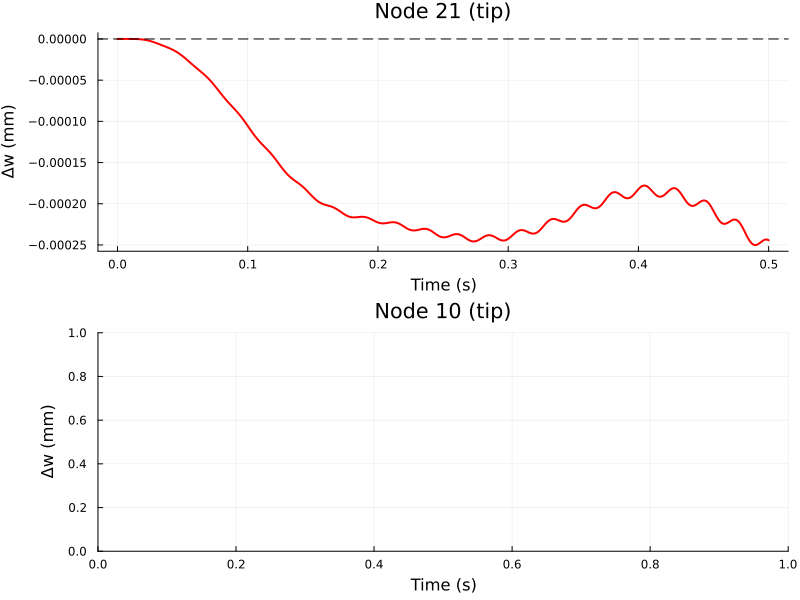

Difference plot saved → beam_chain_difference.png


In [9]:
# ----------------------------------------------------------------
# Plot difference between pure beam and beam with chain at node 3
# ----------------------------------------------------------------

# Time vector (same for both simulations)
t = res.t

# Nodes we want to compare
nodes_to_plot = [1001]   # chain location and tip

# Extract displacements for pure beam (res)
w_pure = res.w_beam
beam_nodes_pure = res.beam_nodes

# Extract displacements for coupled beam (stiff)
w_coupled = stiff.w_beam
beam_nodes_coupled = stiff.beam_nodes

# Create a figure with two subplots: one for node 3, one for node 10
p_diff = plot(layout=(2,1), size=(800,600),
              xlabel="Time (s)", ylabel="Δw (mm)",
              title=["Node 21 (tip)" "Node 10 (tip)"],
              legend=false)

for (i, node) in enumerate(nodes_to_plot)
    # Find row index in each result
    idx_pure = findfirst(==(node), beam_nodes_pure)
    idx_coupled = findfirst(==(node), beam_nodes_coupled)
    
    if !isnothing(idx_pure) && !isnothing(idx_coupled)
        Δw = (w_coupled[idx_coupled, :] - w_pure[idx_pure, :]) * 1e3   # convert to mm
        plot!(p_diff[i], t, Δw, lw=2, color=:red)
        # Add zero line for reference
        hline!(p_diff[i], [0.0], lw=1, color=:black, linestyle=:dash)
    end
end

display(p_diff)
savefig(p_diff, "beam_chain_difference.png")
println("Difference plot saved → beam_chain_difference.png")

Node 1001:
  Pure beam   max |w| = 0.029032 mm
  Coupled beam max |w| = 0.028826 mm


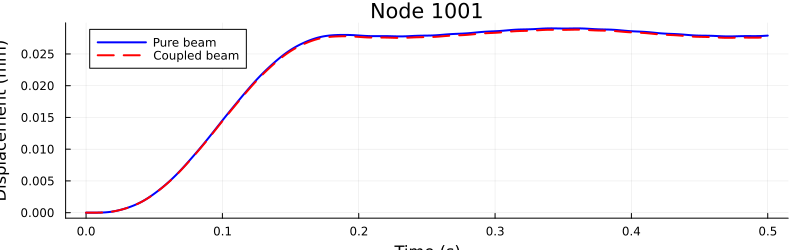

"c:\\Users\\ido37\\OneDrive\\Desktop\\Desktop\\UIUC\\Goza Research\\Amber Goza Research Stuff\\beam_chain_displacement_comparison.png"

In [11]:
# ----------------------------------------------------------------
# Plot displacement comparison for selected nodes
# ----------------------------------------------------------------

t = res.t

nodes_to_plot = [1001]   # your node list

w_pure = res.w_beam
w_coupled = stiff.w_beam
beam_nodes_pure = res.beam_nodes
beam_nodes_coupled = stiff.beam_nodes

n_plots = length(nodes_to_plot)

p_disp = plot(layout = (n_plots, 1),
              size = (800, 250 * n_plots),
              xlabel = "Time (s)",
              ylabel = "Displacement (mm)",
              legend = :best)

for (i, node) in enumerate(nodes_to_plot)
    idx_pure = findfirst(==(node), beam_nodes_pure)
    idx_coupled = findfirst(==(node), beam_nodes_coupled)
    
    if !isnothing(idx_pure) && !isnothing(idx_coupled)
        # Displacements in mm
        w_pure_node = w_pure[idx_pure, :] * 1e3
        w_coupled_node = w_coupled[idx_coupled, :] * 1e3
        
        # ---- Print maximum (absolute) displacement ----
        max_pure = maximum(abs.(w_pure_node))
        max_coupled = maximum(abs.(w_coupled_node))
        println("Node $node:")
        println("  Pure beam   max |w| = $(round(max_pure, digits=6)) mm")
        println("  Coupled beam max |w| = $(round(max_coupled, digits=6)) mm")
        
        # ---- Plot ----
        plot!(p_disp[i], t, w_pure_node,
              lw=2, color=:blue, label="Pure beam")
        plot!(p_disp[i], t, w_coupled_node,
              lw=2, color=:red, label="Coupled beam", linestyle=:dash)
        title!(p_disp[i], "Node $node")
    end
end

display(p_disp)
savefig(p_disp, "beam_chain_displacement_comparison.png")